# Diabetes 데이터셋 SVR RFECV 회귀

## 개요
- SVR을 활용한 RFECV 피처 선택 (회귀 문제)
- 선형 SVR로 피처 선택, RBF SVR로 예측
- Negative MSE 기준 최적 피처 탐색

## 핵심 전략
선형 SVR(coef_)로 중요 피처 선정, RBF 커널로 비선형 회귀

## 주요 단계
1. Diabetes 데이터셋 로드
2. 선형 SVR + RFECV 설정
3. Pipeline 구축 및 학습
4. 회귀 성능 평가 (RMSE, R2)
5. 성능 시각화

## 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

## 1. 데이터 로드

**Diabetes 데이터셋**
- 442개 샘플, 10개 피처
- 당뇨병 진행도 예측 (회귀 문제)
- 타겟: 1년 후 질병 진행 정도

In [2]:
# 데이터 로드
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(diabetes.feature_names)}")
print(f"\n타겟 통계:")
print(f"  평균: {y.mean():.2f}")
print(f"  범위: {y.min():.0f} ~ {y.max():.0f}")

데이터 크기: (442, 10)
피처 목록: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

타겟 통계:
  평균: 152.13
  범위: 25 ~ 346


**데이터 샘플 확인**

In [3]:
# 데이터 샘플
print("데이터 샘플:")
print(X.head())
print(f"\n기술 통계:")
print(X.describe())

데이터 샘플:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  

기술 통계:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.0722

**학습/테스트 데이터 분리**

In [4]:
# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (353, 10), Test: (89, 10)


## 2. SVR Pipeline 구성 전략

**핵심 아이디어**
- 피처 선택: 선형 SVR (coef_ 속성 필요)
- 최종 예측: RBF 커널 (비선형 회귀)

**분류 vs 회귀 차이점**
- 분류: SVC, StratifiedKFold, accuracy
- 회귀: SVR, KFold, neg_mean_squared_error/r2

**scoring: neg_mean_squared_error**
- MSE를 최소화 (작을수록 좋음)
- sklearn은 높을수록 좋은 방향이 기본이므로 negative 사용
- 0에 가까울수록 (즉, 절댓값이 작을수록) 성능 좋음

## 3. 피처 선택용 SVR 설정

**선형 SVR 생성**
- kernel=linear: coef_ 속성 생성
- RFECV에서 피처 중요도 계산

In [5]:
# 피처 선택용 선형 SVR
svr_linear = SVR(kernel="linear")
print("선형 SVR 생성 완료 (피처 선택용)")

선형 SVR 생성 완료 (피처 선택용)


## 4. RFECV 설정

**RFECV 파라미터 (회귀 버전)**
- estimator: 선형 SVR
- step=1: 한 번에 1개씩 제거
- cv: KFold(5) - 회귀는 KFold 사용
- scoring: neg_mean_squared_error
- min_features_to_select=1

In [6]:
# RFECV 설정 (회귀용)
rfecv = RFECV(
    estimator=svr_linear,
    step=1,
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    min_features_to_select=1
)

print("RFECV 설정 완료 (neg_mean_squared_error 기준)")

RFECV 설정 완료 (neg_mean_squared_error 기준)


## 5. Pipeline 구축

**Pipeline 3단계**
1. StandardScaler: 스케일링 (SVR 필수)
2. RFECV + 선형 SVR: 최적 피처 선정
3. RBF SVR: 비선형 회귀 예측

**RBF SVR 하이퍼파라미터**
- C=10.0: 규제 강도
- epsilon=0.1: 오차 허용 범위

In [7]:
# Pipeline 구축
pipe_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', rfecv),
    ('regressor', SVR(kernel='rbf', C=10.0, epsilon=0.1))
])

print("Pipeline 구성 완료")
print("\nPipeline 구조:")
print(pipe_svr)

Pipeline 구성 완료

Pipeline 구조:
Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection',
                 RFECV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=SVR(kernel='linear'),
                       scoring='neg_mean_squared_error')),
                ('regressor', SVR(C=10.0))])


## 6. 모델 학습

**학습 과정**
1. 데이터 스케일링
2. RFECV로 최적 피처 탐색
3. RBF SVR로 회귀 학습

In [8]:
# 학습
print("Training SVR Pipeline with RFECV...")
print("(교차검증 수행 중... 시간이 소요됩니다)")
pipe_svr.fit(X_train, y_train)
print("\n학습 완료!")

Training SVR Pipeline with RFECV...
(교차검증 수행 중... 시간이 소요됩니다)

학습 완료!


## 7. 결과 진단

**선택된 피처 확인**

In [9]:
# 선택된 피처 정보 추출
fs_step = pipe_svr.named_steps['feature_selection']
n_features = fs_step.n_features_
selected_indices = fs_step.support_
selected_features = np.array(diabetes.feature_names)[selected_indices]

print("[결과 진단]")
print(f"알고리즘이 선택한 최적의 피처 개수: {n_features}개")
print(f"\n선택된 피처 목록:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

[결과 진단]
알고리즘이 선택한 최적의 피처 개수: 5개

선택된 피처 목록:
  1. sex
  2. bmi
  3. bp
  4. s3
  5. s5


**피처별 순위**

In [10]:
# 피처별 순위 확인
feature_ranking = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Rank': fs_step.ranking_,
    'Selected': fs_step.support_
}).sort_values('Rank')

print("\n피처별 순위 (1이 선택됨):")
print(feature_ranking)


피처별 순위 (1이 선택됨):
  Feature  Rank  Selected
1     sex     1      True
2     bmi     1      True
3      bp     1      True
6      s3     1      True
8      s5     1      True
5      s2     2     False
7      s4     3     False
4      s1     4     False
9      s6     5     False
0     age     6     False


## 8. 회귀 성능 평가

**평가 지표**
- RMSE: Root Mean Squared Error (낮을수록 좋음)
- R2 Score: 결정계수 (1에 가까울수록 좋음)

In [11]:
# 예측 및 평가
y_pred = pipe_svr.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Pipeline Test RMSE: {rmse:.4f}")
print(f"Pipeline Test R2 Score: {r2:.4f}")

Pipeline Test RMSE: 49.5559
Pipeline Test R2 Score: 0.5365


## 9. 모든 피처 vs 선택된 피처 비교

In [12]:
# 모든 피처 사용
pipe_all = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', SVR(kernel='rbf', C=10.0, epsilon=0.1))
])

print("모든 피처로 SVR 학습 중...")
pipe_all.fit(X_train, y_train)
y_pred_all = pipe_all.predict(X_test)
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all))
r2_all = r2_score(y_test, y_pred_all)

# 비교
print("\n성능 비교:")
print(f"모든 피처 ({len(diabetes.feature_names)}개):")
print(f"  RMSE = {rmse_all:.4f}, R2 = {r2_all:.4f}")
print(f"\n선택된 피처 ({n_features}개):")
print(f"  RMSE = {rmse:.4f}, R2 = {r2:.4f}")
print(f"\nRMSE 개선: {rmse_all - rmse:+.4f}")
print(f"R2 개선: {r2 - r2_all:+.4f}")

모든 피처로 SVR 학습 중...

성능 비교:
모든 피처 (10개):
  RMSE = 51.7918, R2 = 0.4937

선택된 피처 (5개):
  RMSE = 49.5559, R2 = 0.5365

RMSE 개선: +2.2359
R2 개선: +0.0428


## 10. 예측 결과 시각화

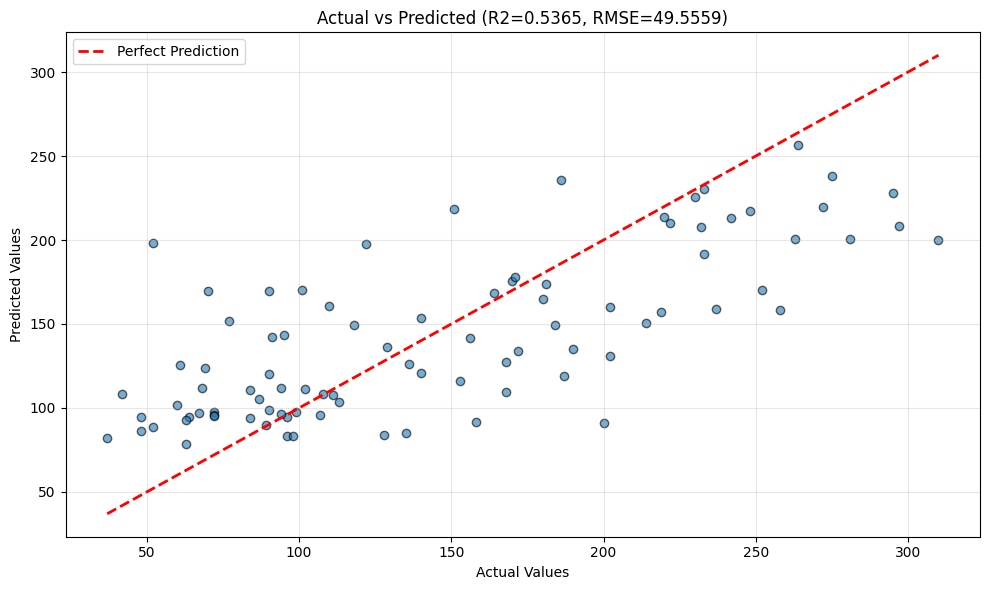

In [13]:
# 실제값 vs 예측값
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted (R2={r2:.4f}, RMSE={rmse:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. RFECV 성능 변화 시각화

**Negative MSE 해석**
- 0에 가까울수록 (절댓값 작을수록) 성능 좋음
- -1000보다 -500이 더 좋은 성능
- 최적 지점: 가장 0에 가까운 값

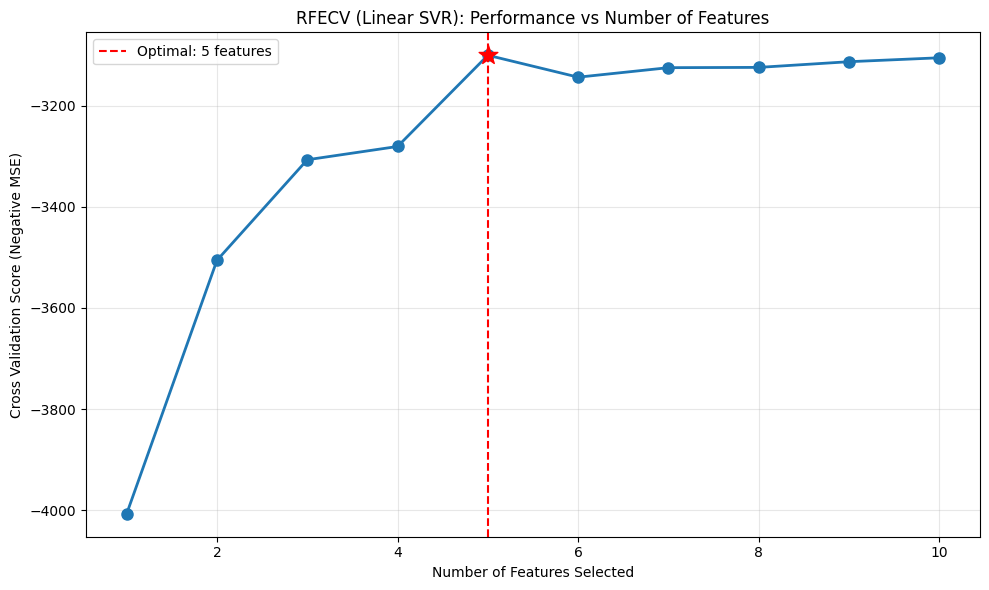


최적 Negative MSE: -3100.60
(0에 가까울수록 좋음)


In [14]:
# RFECV 성능 변화 시각화
plt.figure(figsize=(10, 6))
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross Validation Score (Negative MSE)")

cv_scores = fs_step.cv_results_['mean_test_score']
plt.plot(
    range(1, len(cv_scores) + 1),
    cv_scores,
    marker='o',
    linewidth=2,
    markersize=8
)

# 최적 지점 표시
optimal_score = cv_scores[n_features - 1]
plt.axvline(x=n_features, color='r', linestyle='--',
            label=f'Optimal: {n_features} features')
plt.scatter([n_features], [optimal_score],
            color='red', s=200, zorder=5, marker='*')

plt.title("RFECV (Linear SVR): Performance vs Number of Features")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n최적 Negative MSE: {optimal_score:.2f}")
print(f"(0에 가까울수록 좋음)")

## 12. 교차검증 점수 상세 분석

In [15]:
# 피처 개수별 점수 분석
cv_results_df = pd.DataFrame({
    'Num_Features': range(1, len(cv_scores) + 1),
    'Neg_MSE': cv_scores,
    'Std': fs_step.cv_results_['std_test_score']
})

print("\n피처 개수별 교차검증 점수:")
print(cv_results_df)

print(f"\n최고 점수: {cv_results_df['Neg_MSE'].max():.2f}")
print(f"최적 선택: {n_features}개 피처")


피처 개수별 교차검증 점수:
   Num_Features      Neg_MSE         Std
0             1 -4006.829226  205.689659
1             2 -3505.854030  259.488078
2             3 -3307.126445  303.979165
3             4 -3280.876936  360.769128
4             5 -3100.598679  300.275467
5             6 -3143.915822  257.201081
6             7 -3125.118776  286.641483
7             8 -3124.577263  276.191418
8             9 -3113.332457  275.255856
9            10 -3105.576244  253.347573

최고 점수: -3100.60
최적 선택: 5개 피처


## 정리

**SVR + RFECV (회귀)**
- 선형 SVR: 피처 중요도 평가
- RBF SVR: 비선형 회귀 예측
- neg_mean_squared_error: MSE 최소화

**분류 vs 회귀 차이**
- 분류: SVC, StratifiedKFold, accuracy
- 회귀: SVR, KFold, neg_mean_squared_error/r2
- 타겟: 범주형 vs 연속형

**Negative MSE 해석**
- sklearn은 높은 값이 좋은 방향
- MSE는 낮을수록 좋으므로 negative 사용
- -500이 -1000보다 좋은 성능

**SVR 특징**
- 스케일링 필수
- 소규모 데이터 적합
- C, epsilon 하이퍼파라미터 중요
- 연산 비용 높음

**성능 평가**
- RMSE: 예측 오차 크기
- R2: 설명력 (0~1)
- 피처 선택으로 성능 개선 확인

**추가 실험 아이디어**
- GridSearchCV로 C, epsilon 최적화
- 다양한 scoring 지표 (r2, neg_mean_absolute_error)
- 다른 커널 조합 테스트
- RandomForestRegressor와 비교